# Raw Data Inspection

This notebook inspects the archival CCD dataset selected from the NSF NOIRLab Astro Data Archive.

**Dataset**
- Telescope: CTIO 0.9 m
- Instrument: CFCCD / CCD Imager
- Detector: Tek2K_3
- Science target: 158P
- Filter: r
- Science exposure: 60 s
- Calibration frames: 10 zero/bias frames and 5 R-band dome flats

No dark frames were available for the selected observing night.

The goal is to verify the FITS structure, metadata, dimensions and raw image appearance before calibration.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
PROJECT_DIR = Path("..").resolve()

BIAS_DIR = PROJECT_DIR / "Bias"
FLAT_DIR = PROJECT_DIR / "Flats"

bias_files = sorted(BIAS_DIR.glob("*.fits*"))
flat_files = sorted(FLAT_DIR.glob("*.fits*"))
science_candidates = sorted(PROJECT_DIR.glob("*.fits*"))

print(f"Project: {PROJECT_DIR}")
print(f"Bias frames: {len(bias_files)}")
print(f"Flat frames: {len(flat_files)}")
print(f"Science candidates: {[f.name for f in science_candidates]}")

Project: C:\Users\rodri\NoirLab
Bias frames: 10
Flat frames: 5
Science candidates: ['c09i_180419_050252_ori.fits.fz']


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""
    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i
    raise ValueError(f"No 2D image found in {filename}")

## Science exposure

In [4]:
science_file = science_candidates[0]
science_hdu = get_image_hdu(science_file)

with fits.open(science_file) as hdul:
    hdul.info()
    science_data = hdul[science_hdu].data.astype(float)
    science_header = hdul[science_hdu].header

print("\nSelected science file:", science_file.name)
print("Shape:", science_data.shape)

for key in [
    "OBJECT", "IMAGETYP", "DATE-OBS", "EXPTIME",
    "DETECTOR", "CCDSUM", "FILTER1", "FILTER2", "FILTERS"
]:
    print(f"{key:10s}: {science_header.get(key, 'Not found')}")

Filename: C:\Users\rodri\NoirLab\c09i_180419_050252_ori.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      30   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    118   (2168, 2048)   int16 (rescales to uint16)   

Selected science file: c09i_180419_050252_ori.fits.fz
Shape: (2048, 2168)
OBJECT    : 158P
IMAGETYP  : object
DATE-OBS  : 2018-04-19T05:02:52.157
EXPTIME   : 60.0
DETECTOR  : Tek2K_3
CCDSUM    : 1 1
FILTER1   : dia
FILTER2   : r
FILTERS   : dia r


Minimum : 879.00 ADU
Maximum : 62759.00 ADU
Mean    : 1269.51 ADU
Median  : 1226.00 ADU
Std     : 1550.10 ADU


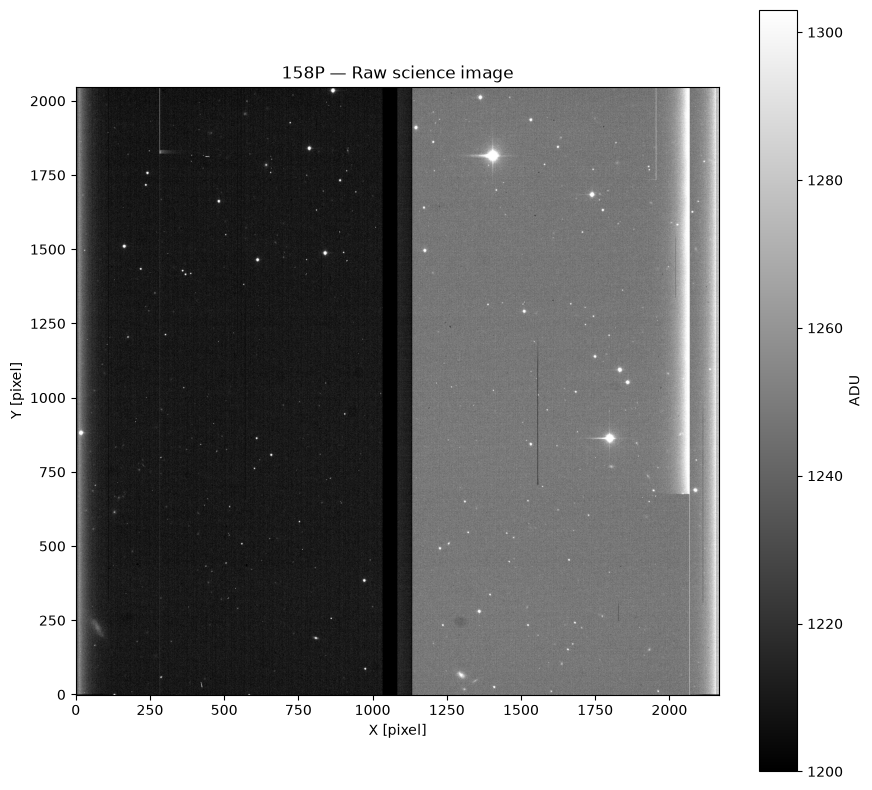

In [5]:
print(f"Minimum : {np.nanmin(science_data):.2f} ADU")
print(f"Maximum : {np.nanmax(science_data):.2f} ADU")
print(f"Mean    : {np.nanmean(science_data):.2f} ADU")
print(f"Median  : {np.nanmedian(science_data):.2f} ADU")
print(f"Std     : {np.nanstd(science_data):.2f} ADU")

vmin, vmax = np.nanpercentile(science_data, [5, 99.5])

plt.figure(figsize=(9, 8))
plt.imshow(science_data, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Raw science image")
plt.tight_layout()
plt.show()

## Bias / zero frame

OBJECT    : Bias
IMAGETYP  : zero
EXPTIME   : 0.0
DETECTOR  : Tek2K_3
CCDSUM    : 1 1
Shape: (2048, 2168)


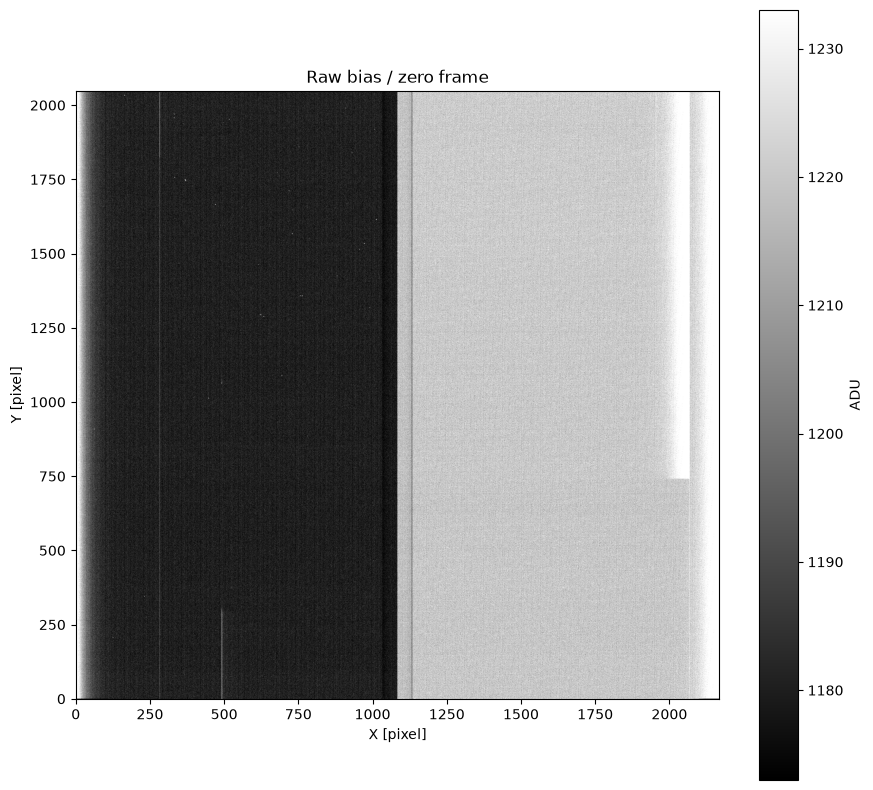

In [6]:
bias_file = bias_files[0]
bias_hdu = get_image_hdu(bias_file)

with fits.open(bias_file) as hdul:
    bias_data = hdul[bias_hdu].data.astype(float)
    bias_header = hdul[bias_hdu].header

for key in ["OBJECT", "IMAGETYP", "EXPTIME", "DETECTOR", "CCDSUM"]:
    print(f"{key:10s}: {bias_header.get(key, 'Not found')}")

print("Shape:", bias_data.shape)

vmin, vmax = np.nanpercentile(bias_data, [5, 95])

plt.figure(figsize=(9, 8))
plt.imshow(bias_data, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Raw bias / zero frame")
plt.tight_layout()
plt.show()

## R-band dome flat

OBJECT    : R-dflat
IMAGETYP  : dflat
EXPTIME   : 120.0
FILTER2   : r
DETECTOR  : Tek2K_3
CCDSUM    : 1 1
Shape: (2048, 2168)


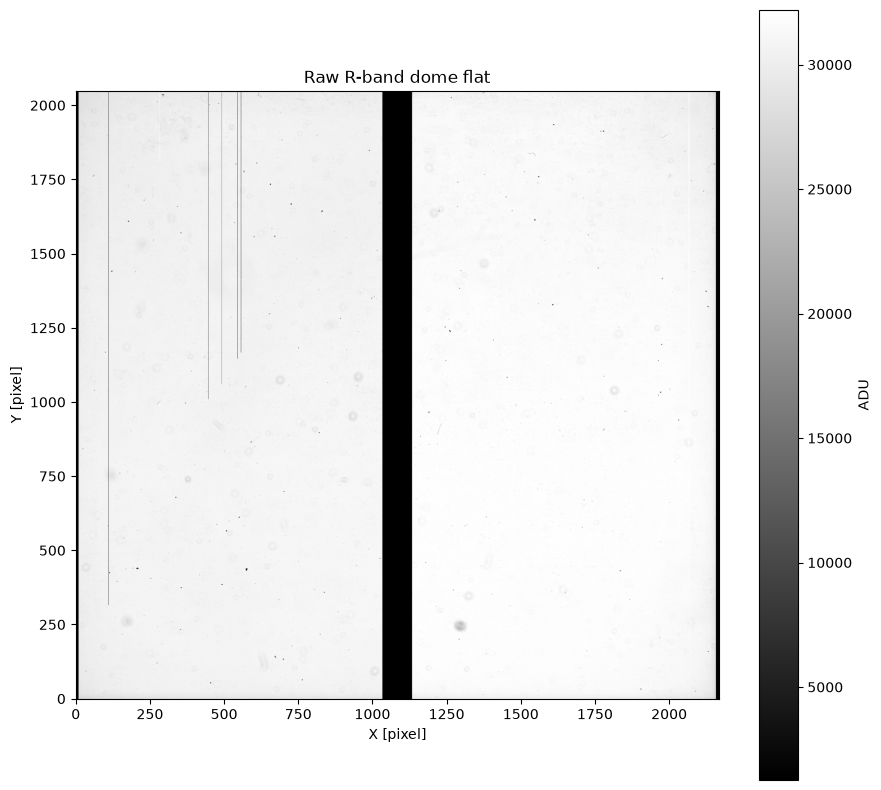

In [7]:
flat_file = flat_files[0]
flat_hdu = get_image_hdu(flat_file)

with fits.open(flat_file) as hdul:
    flat_data = hdul[flat_hdu].data.astype(float)
    flat_header = hdul[flat_hdu].header

for key in ["OBJECT", "IMAGETYP", "EXPTIME", "FILTER2", "DETECTOR", "CCDSUM"]:
    print(f"{key:10s}: {flat_header.get(key, 'Not found')}")

print("Shape:", flat_data.shape)

vmin, vmax = np.nanpercentile(flat_data, [5, 95])

plt.figure(figsize=(9, 8))
plt.imshow(flat_data, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Raw R-band dome flat")
plt.tight_layout()
plt.show()

## Summary

The three image types have compatible detector geometry and metadata. The science image and calibration frames can therefore be processed with the same two-amplifier overscan and trimming scheme in the following notebooks.